In [1]:
import networkx as nx            #importing networkx library to create graph
import matplotlib.pyplot as plt  #importing matplotlib library to visualize graph 
import pandas as pd              #importing pandas library to to read csv file containing public transport data

In [2]:
#reading csv file containing data on subway stations in Tokyo
df = pd.read_csv('D:/Data Science/Programming Fundamentals for DS/labs/tokyoSubwayDataset.csv')

#displaying the csv file in the form of a table
display(df)

,Ser. No.,Station No.,Station Name,Distance from Previous Station,Distance from First Station,Interchange,Latitude(N),Longitude(E)
0,1,G01,Shibuya,0.0,0.0,"Z01,F16",35.658514,139.701330
1,2,G02,Omote-sando,1.3,1.3,"C04,Z02",35.665148,139.712521
2,3,G03,Gaiemmae,0.7,2.0,NaN,35.670650,139.718145
3,4,G04,Aoyama-itchome,0.7,2.7,"Z03,E24",35.672922,139.724278
4,5,G05,Akasaka-mitsuke,1.3,4.0,"M13,Y16,Z04,N07",35.676821,139.737119
...,...,...,...,...,...,...,...,...
288,289,E34,Shin-egota,1.6,35.3,NaN,35.732300,139.670800
289,290,E35,Nerima,1.6,36.9,NaN,35.737778,139.653568
290,291,E36,Toshimaen,0.9,37.8,NaN,35.742400,139.648000
291,292,E37,Nerima-kasugacho,1.5,39.3,NaN,35.751700,139.640000


In [3]:
#converting the csv file into a dataframe named subwayStops
subwayStops = pd.DataFrame(df)

In [4]:
#creating a Graph object from networkx library
G = nx.MultiGraph()

In [1]:
#creating an empty list to contain Station names
x=[] 
#creating an empty list to contain Station names
y=[] 
#creating an empty list to contain edges between nodes (Station names) from same line
edgeList1=[]  
#creating an empty list to contain edges between nodes (Station names) from different lines
edgeList2=[]  
#creating an empty list to contain weighted edges
weightedEdges1=[]
#creating an empty list to contain weighted edges
weightedEdges2=[]

#Looping through all rows of dataframe
for i in range(len(subwayStops)):
    
    # If item exists after ith index and ith item has non-zero 'Distance from First Station' and i+1 th item has zero 'Distance from First Station'
    # then proceed
    if i+1 < len(subwayStops) and subwayStops['Distance from First Station'][i]!=0 and subwayStops['Distance from First Station'][i+1]==0:
        #If 'Interchange' at ith index has NaN value then do nothing
        if subwayStops['Interchange'].iloc[i] != subwayStops['Interchange'].iloc[i]:
            pass
        #If 'Interchange' at (i+1)th index has non-NaN value then:
        else:
            # Split the value of 'Interchange' at ith index, into a list connectedStations of multiple items (stations), 
            # on the basis of comma separator
            connectedStations = subwayStops['Interchange'].iloc[i].split(',')
            # Looping through the stations in the list 'connectedStations'
            for station in connectedStations:
                edgeList1.append((subwayStops['Station No.'].iloc[i],station))
                weightedEdges1.append((subwayStops['Station No.'].iloc[i],station,1.0))
        continue
    # If item exists after ith index then append 'Staion No.' at ith index in list x and at (i+1)th index in list y    
    elif i+1 < len(subwayStops):
        x.append(subwayStops['Station No.'][i])
        y.append(subwayStops['Station No.'][i+1])
    
        if subwayStops['Interchange'].iloc[i] != subwayStops['Interchange'].iloc[i]:
            pass
        else:
            connectedStations = subwayStops['Interchange'].iloc[i].split(',')
            for station in connectedStations:
                edgeList1.append((subwayStops['Station No.'].iloc[i],station))
                weightedEdges1.append((subwayStops['Station No.'].iloc[i],station,1.0))
      
edgeList2=list(zip(x,y))
edgeList1.extend(edgeList2)
weightedEdges2 = list(zip(x,y,subwayStops['Distance from Previous Station']))
weightedEdges1.extend(weightedEdges2)

#G.add_edges_from(edgeList1)
G.add_weighted_edges_from(weightedEdges1)
coords = list(zip(subwayStops['Latitude(N)'],subwayStops['Longitude(E)']))
pos = dict(zip(subwayStops['Station No.'], coords)) 

NameError: name 'subwayStops' is not defined

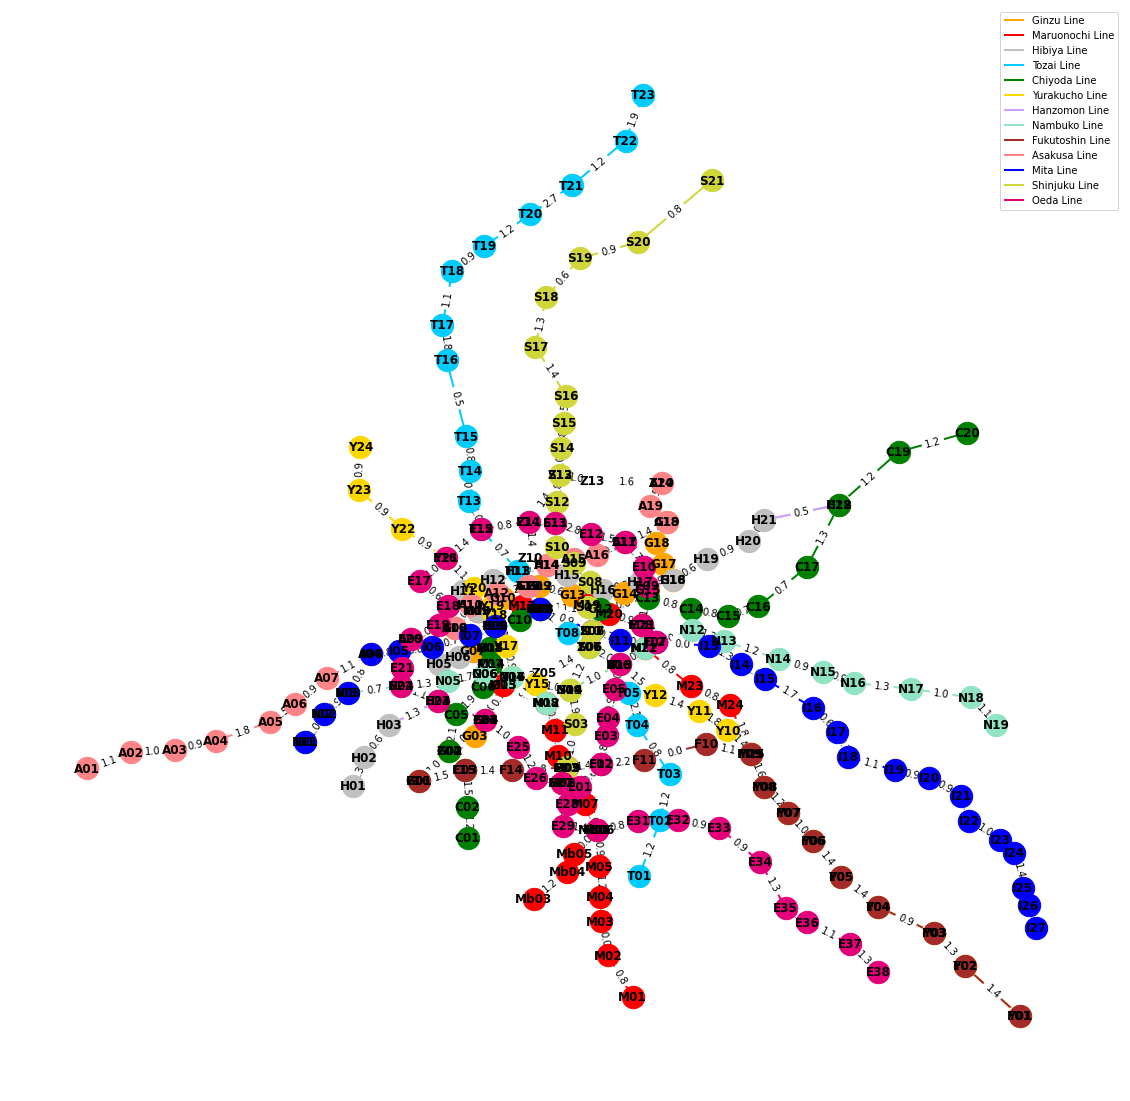

In [13]:
GNodes = []   # G = Ginza (orange)
MNodes = []   # M,Mb = Maruonochi (red)
HNodes = []   # H = Hibiya (silver)
TNodes = []   # T = Tozai (Sky blue)
CNodes = []   # C = Chiyoda (Green)
YNodes = []   # Y = Yurakucho (Gold)
ZNodes = []   # Z = Hanzomon (Purple)
NNodes = []   # N = Nambuko (Emerald/teal)
FNodes = []   # F = Fukutoshin (Brown)
ANodes = []   # A = Asakusa (Rose red)
INodes = []   # I = Mita (Blue)
SNodes = []   # S = Shinjuku (Leaf)
ENodes = []   # E = Oeda (Magenta)
listofLists=[]

plt.figure(figsize=(20,20))

for i in range(len(list(G.nodes))):

    if 'G' in list(G.nodes)[i]:
        GNodes.append(list(G.nodes)[i])
    elif 'M' in list(G.nodes)[i]:
        MNodes.append(list(G.nodes)[i])
    elif 'H' in list(G.nodes)[i]:
        HNodes.append(list(G.nodes)[i])
    elif 'T' in list(G.nodes)[i]:
        TNodes.append(list(G.nodes)[i])
    elif 'C' in list(G.nodes)[i]:
        CNodes.append(list(G.nodes)[i])
    elif 'Y' in list(G.nodes)[i]:
        YNodes.append(list(G.nodes)[i])
    elif 'Z' in list(G.nodes)[i]:
        ZNodes.append(list(G.nodes)[i])
    elif 'N' in list(G.nodes)[i]:
        NNodes.append(list(G.nodes)[i])
    elif 'F' in list(G.nodes)[i]:
        FNodes.append(list(G.nodes)[i])
    elif 'A' in list(G.nodes)[i]:
        ANodes.append(list(G.nodes)[i])
    elif 'I' in list(G.nodes)[i]:
        INodes.append(list(G.nodes)[i])
    elif 'S' in list(G.nodes)[i]:
        SNodes.append(list(G.nodes)[i])
    elif 'E' in list(G.nodes)[i]:
        ENodes.append(list(G.nodes)[i])

listofLists.append((GNodes, 'orange', 'Ginzu Line'))
listofLists.append((MNodes, 'red', 'Maruonochi Line'))
listofLists.append((HNodes, 'silver', 'Hibiya Line'))
listofLists.append((TNodes, '#00ccff', 'Tozai Line'))
listofLists.append((CNodes, 'green', 'Chiyoda Line'))
listofLists.append((YNodes, 'gold', 'Yurakucho Line'))
listofLists.append((HNodes, '#cf9fff', 'Hanzomon Line'))
listofLists.append((NNodes, '#90e4c1', 'Nambuko Line'))
listofLists.append((FNodes, 'brown', 'Fukutoshin Line'))
listofLists.append((ANodes, '#ff8488', 'Asakusa Line'))
listofLists.append((INodes, 'blue', 'Mita Line'))
listofLists.append((SNodes, '#d1d63b', 'Shinjuku Line'))
listofLists.append((ENodes, '#e40078', 'Oeda Line'))
        
for item in listofLists:
    nx.draw_networkx_nodes(G, pos, nodelist=item[0], node_size=500, node_color=item[1], node_shape='o', label=None)
    item[0].clear()

listofLists.clear()

for item in weightedEdges2:
    if 'G' in item[0]:
        GNodes.append(item)
    if 'M' in item[0]:
        MNodes.append(item)
    if 'H' in item[0]:
        HNodes.append(item)
    if 'T' in item[0]:
        TNodes.append(item)
    if 'C' in item[0]:
        CNodes.append(item)
    if 'Y' in item[0]:
        YNodes.append(item)
    if 'Z' in item[0]:
        ZNodes.append(item)
    if 'N' in item[0]:
        NNodes.append(item)
    if 'F' in item[0]:
        FNodes.append(item)
    if 'A' in item[0]:
        ANodes.append(item)
    if 'I' in item[0]:
        INodes.append(item)
    if 'S' in item[0]:
        SNodes.append(item)
    if 'E' in item[0]:
        ENodes.append(item)
    
listofLists.append((GNodes, 'orange', 'Ginzu Line'))
listofLists.append((MNodes, 'red', 'Maruonochi Line'))
listofLists.append((HNodes, 'silver', 'Hibiya Line'))
listofLists.append((TNodes, '#00ccff', 'Tozai Line'))
listofLists.append((CNodes, 'green', 'Chiyoda Line'))
listofLists.append((YNodes, 'gold', 'Yurakucho Line'))
listofLists.append((HNodes, '#cf9fff', 'Hanzomon Line'))
listofLists.append((NNodes, '#90e4c1', 'Nambuko Line'))
listofLists.append((FNodes, 'brown', 'Fukutoshin Line'))
listofLists.append((ANodes, '#ff8488', 'Asakusa Line'))
listofLists.append((INodes, 'blue', 'Mita Line'))
listofLists.append((SNodes, '#d1d63b', 'Shinjuku Line'))
listofLists.append((ENodes, '#e40078', 'Oeda Line'))

for item in listofLists:
    nx.draw_networkx_edges(G, pos, edgelist=item[0], width=2.0, edge_color=item[1], style='solid', arrowsize=10, label=item[-1], node_size=500, node_shape='o', connectionstyle='arc3, rad = 0.1', min_source_margin=0, min_target_margin=0)

edge_labels = dict([((a,b),d['weight']) for a,b,d in G.edges(data=True)])
nx.draw_networkx_labels(G, pos, labels=None, font_size=12, font_color='k', font_family='sans-serif', font_weight='bold', horizontalalignment='center', verticalalignment='center', clip_on=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, label_pos=0.5, font_size=10, font_color='k', font_family='sans-serif', font_weight='normal', horizontalalignment='center', verticalalignment='center', rotate=True, clip_on=True)

#plt.savefig("graph.pdf")
plt.legend(scatterpoints = 1)
plt.axis('off')
plt.show()